In [1]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import matplotlib.animation as animation
from IPython.display import HTML
warnings.filterwarnings('ignore')  
plt.rcParams['text.usetex'] = True

# FD Method

### Burgers Equation | MacCormack scheme (predictor–corrector finite difference method)

$\qquad\displaystyle \partial_t u + u\partial_x u = \nu\partial_{x}^2u$                                                  

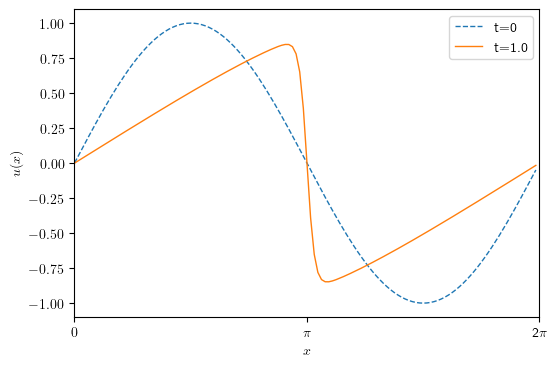

In [7]:
nu = 0.1
tf = 1
dt = 0.001
nsteps = int(tf/dt)

L = 2*np.pi
N = 128
h = L / N
j = np.arange(0,N)
x = j*h

init_f   = np.sin(x)

f        = np.zeros(N+2)
fmid     = np.zeros(N+2)
f[1:N+1] = init_f
f[0]     = init_f[-1]
f[N+1]   = init_f[0]
fx       = f.copy()
for time_ind in range(nsteps+2):
    fmid[1:N+1] = f[1:N+1] - (dt/(2*h))*f[1:N+1]*(f[2:N+2]-f[0:N]) + (nu*dt/(2*h**2))*(f[2:N+2]-2*f[1:N+1]+f[0:N])
    fmid[ 0] = fmid[N]
    fmid[-1] = fmid[1]
    f[1:N+1] = f[1:N+1] - (dt/h)*fmid[1:N+1]*(fmid[2:N+2]-fmid[0:N]) + (nu*dt/h**2)*(fmid[2:N+2]-2*fmid[1:N+1]+fmid[0:N])
    f[ 0] = f[N]
    f[-1] = f[1]
    t= time_ind*dt
    if (time_ind%200 == 0):
        clear_output(wait=True)
        fig, ax1 = plt.subplots(figsize=(6, 4))
        ax1.plot(x, fx[1:N+1],'--', lw = 1, label = 't=0')
        ax1.plot(x, f[1:N+1], lw = 1, label = f't={t}')
        ax1.set_xlim(0,2*np.pi)
        ax1.set_xlabel('$x$',fontsize=10)
        ax1.set_ylabel('$u(x)$',fontsize=10)
        ax1.set_xticks([0, np.pi, 2*np.pi])
        ax1.set_xticklabels(['$0$', '$\pi$', '2$\pi$'])
        ax1.legend()
        plt.show()

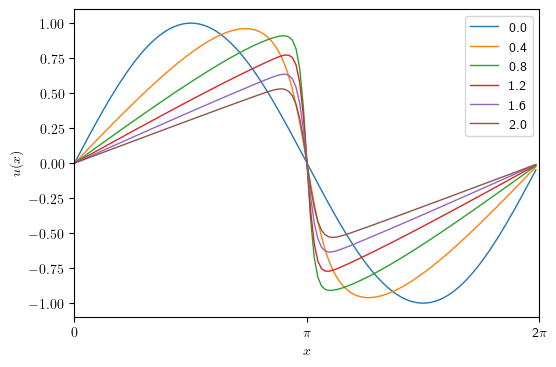

In [8]:
nu = 0.1
tf = 2
dt = 0.001
nsteps = int(tf/dt)

L = 2*np.pi
N = 128
h = L / N
j = np.arange(0,N)
x = j*h

init_f   = np.sin(x)

f        = np.zeros(N+2)
fmid     = np.zeros(N+2)
f[1:N+1] = init_f
f[0]     = init_f[-1]
f[N+1]   = init_f[0]

fig, ax1 = plt.subplots(figsize=(6, 4))

for time_ind in range(nsteps+2):
    fmid[1:N+1] = f[1:N+1] - (dt/(2*h))*f[1:N+1]*(f[2:N+2]-f[0:N]) + (nu*dt/(2*h**2))*(f[2:N+2]-2*f[1:N+1]+f[0:N])
    fmid[ 0] = fmid[N]
    fmid[-1] = fmid[1]
    f[1:N+1] = f[1:N+1] - (dt/h)*fmid[1:N+1]*(fmid[2:N+2]-fmid[0:N]) + (nu*dt/h**2)*(fmid[2:N+2]-2*fmid[1:N+1]+fmid[0:N])
    f[ 0] = f[N]
    f[-1] = f[1]
    t= time_ind*dt
    if (time_ind%400 == 0):
        ax1.plot(x, f[1:N+1], lw = 1, label = t)
ax1.set_xlim(0,2*np.pi)
ax1.set_xlabel('$x$',fontsize=10)
ax1.set_ylabel('$u(x)$',fontsize=10)
ax1.set_xticks([0, np.pi, 2*np.pi])
ax1.set_xticklabels(['$0$', '$\pi$', '2$\pi$'])
plt.legend()
plt.show()

## KdV Equation | MacCormack predictor–corrector scheme (2-step explicit FD method)

$\qquad\displaystyle \partial_t u + u\partial_x u = \kappa\partial_{x}^3u$



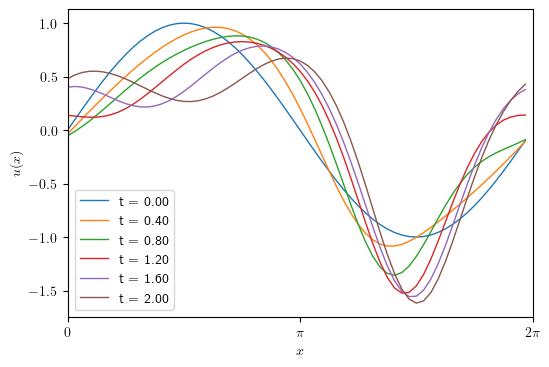

In [13]:
kappa = 0.1
tf = 2      
dt = 0.001 
nsteps = int(tf / dt)

L = 2 * np.pi  
N = 64
h = L / N     
#j = np.arange(0, N)  
#x = j * h 
x = np.linspace(0, L, N, endpoint=False)
init_f = np.sin(x)

f          = np.zeros(N+4)    
fmid       = np.zeros(N+4)
f[2:N+2]   = init_f
f[0:2]     = init_f[-2:]  
f[N+2:N+4] = init_f[0:2]  

fig, ax1 = plt.subplots(figsize=(6, 4))

for time_ind in range(nsteps + 3):
    fmid[2:N+2]   = (f[2:N+2] - (dt / (2*h)) * f[2:N+2] * (f[3:N+3] - f[1:N+1]) 
                    - (kappa * dt / (2*h**3)) * (-f[4:N+4] + 2*f[3:N+3] - 2*f[1:N+1] + f[0:N]))
    fmid[0:2]     = fmid[N:N+2]  
    fmid[N+2:N+4] = fmid[2:4]  
    
    f[2:N+2]      = (f[2:N+2] - (dt / (2*h)) * fmid[2:N+2] * (fmid[3:N+3] - fmid[1:N+1])
                    - (kappa * dt /(h**3)) * (-fmid[4:N+4] + 2*fmid[3:N+3] - 2*fmid[1:N+1] + fmid[0:N]))
    f[0:2]        = f[N:N+2]  
    f[N+2:N+4]    = f[2:4]  
    
    t = time_ind * dt
    if time_ind % 400 == 0:
        ax1.plot(x, f[2:N+2], lw=1, label=f't = {t:.2f}')

ax1.set_xlim(0, 2 * np.pi)
ax1.set_xlabel('$x$', fontsize=10)
ax1.set_ylabel('$u(x)$', fontsize=10)
ax1.set_xticks([0, np.pi, 2*np.pi])
ax1.set_xticklabels(['$0$', '$\pi$', '$2\pi$'])
plt.legend()
plt.show()

# Navier-Strokes Eqn. 

$ \qquad\displaystyle \partial_tu + u\cdot\nabla u = -\frac{1}{\rho}{\nabla p} + \nu\nabla^2 u$                                                                          
$ \qquad\displaystyle \nabla\cdot u=0$                                                                                                                                 
$ \qquad\displaystyle \nabla^2 p=-\rho\nabla\cdot\left[u\cdot\nabla u \right]$                                                                                              
$ \qquad\displaystyle \frac{u^{*}-u_n}{\Delta t}=-u_n\cdot\nabla u_n + \nu\nabla^2u_n $                                                                                      
$ \qquad\displaystyle \nabla^2 p_{n+1} = \frac{\rho}{\Delta t} \nabla\cdot u^*$                                                                                             
$ \qquad\displaystyle u_{n+1}-u^*=-\frac{\Delta t}{\rho} \nabla p_{n+1}$

This is the **incompressible Navier–Stokes equations** in a ND periodic domain size using Chorin-style projection method:


In [2]:
def partial_derivative_x(field):
    diff = np.zeros_like(field)
    diff[1:-1, 1:-1] = (field[2:, 1:-1] - field[0:-2, 1:-1]) / (2 * element_length)
    return diff

def partial_derivative_y(field):
    diff = np.zeros_like(field)
    diff[1:-1, 1:-1] = (field[1:-1, 2:] - field[1:-1, 0:-2]) / (2 * element_length)
    return diff

def laplace(field):
    diff = np.zeros_like(field)
    diff[1:-1, 1:-1] = (field[0:-2, 1:-1] + field[1:-1, 0:-2] - 4 * field[1:-1, 1:-1] +
                        field[2:, 1:-1] + field[1:-1, 2:]) / (element_length ** 2)
    return diff

def divergence(vector_field):
    return partial_derivative_x(vector_field[..., 0]) + partial_derivative_y(vector_field[..., 1])

def gradient(field):
    return np.concatenate((partial_derivative_x(field)[..., np.newaxis],
                           partial_derivative_y(field)[..., np.newaxis]),axis=-1)

def curl_2d(vector_field):
    return partial_derivative_x(vector_field[..., 1]) - partial_derivative_y(vector_field[..., 0])

def advect(field, vector_field):
    backtraced_positions = np.clip(coordinates - TIME_STEP_LENGTH * vector_field, 0.0, DOMAIN_SIZE)
    advected_field = sc.interpolate.interpn(points=(x, y),values=field,xi=backtraced_positions,)
    return advected_field

def diffusion_operator(vector_field_flattened):
    vector_field = vector_field_flattened.reshape(vector_shape)
    diffusion_applied = vector_field - KINEMATIC_VISCOSITY * TIME_STEP_LENGTH * laplace(vector_field)
    return diffusion_applied.flatten()

def poisson_operator(field_flattened):
    field = field_flattened.reshape(scalar_shape)
    poisson_applied = laplace(field)
    return poisson_applied.flatten()


Let the initial velocity field be given by the **Taylor–Green vortex**:

$\qquad\qquad\displaystyle \left\{\begin{array}{rl} u_x(x, y) &= \quad \sin(x) \cos(y), \\ u_y(x, y) &= -\cos(x) \sin(y). \end{array} \right. $                                                                  

* Viscosity: $\nu = 0.1$
* Grid: $32 \times 32$
* Domain: $x, y \in [0, 2\pi)$
* Final time: $T = 1.0$

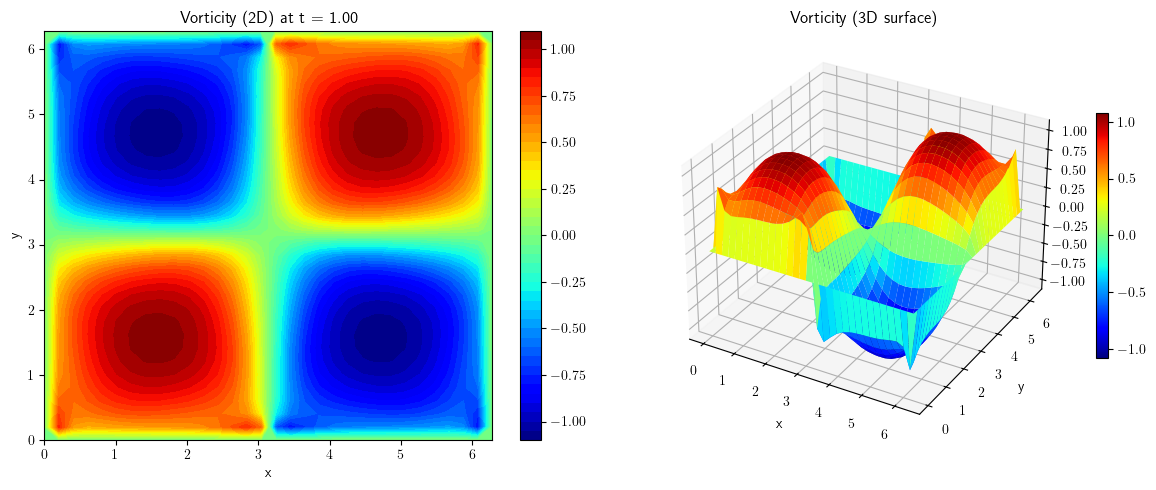

In [3]:
DOMAIN_SIZE         = 2.0 * np.pi
N_POINTS            = 32
TIME_STEP_LENGTH    = 0.001
N_TIME_STEPS        = int(1.0 / TIME_STEP_LENGTH)
KINEMATIC_VISCOSITY = 0.1
MAX_ITER_CG         = None

element_length = DOMAIN_SIZE / (N_POINTS - 1)
scalar_shape   = (N_POINTS, N_POINTS)
scalar_dof     = N_POINTS ** 2
vector_shape   = (N_POINTS, N_POINTS, 2)
vector_dof     = N_POINTS ** 2 * 2

x = np.linspace(0.0, DOMAIN_SIZE, N_POINTS)
y = x.copy()
X, Y = np.meshgrid(x, y, indexing="ij")
coordinates = np.stack((X, Y), axis=-1)

# --- Initial Condition: Taylor–Green Vortex ---
velocities_prev = np.zeros(vector_shape)
velocities_prev[..., 0] =  np.sin(X) * np.cos(Y)  # u_x
velocities_prev[..., 1] = -np.cos(X) * np.sin(Y)  # u_y

# --- Main Time Loop ---
time_current = 0.0
for step in range(N_TIME_STEPS+1):
    time_current += TIME_STEP_LENGTH

    # (1) Semi-Lagrangian advection
    velocities_advected = np.zeros_like(velocities_prev)
    for d in range(2):
        velocities_advected[..., d] = advect(velocities_prev[..., d], velocities_prev)

    # (2) Diffusion step (CG solve)
    v_adv_flat = velocities_advected.flatten()
    v_diff_flat, _ = sc.sparse.linalg.cg(
        A=sc.sparse.linalg.LinearOperator((vector_dof, vector_dof), matvec=diffusion_operator),
        b=v_adv_flat, maxiter=MAX_ITER_CG )
    velocities_diffused = v_diff_flat.reshape(vector_shape)

    # (3) Pressure projection step
    div_field = divergence(velocities_diffused).flatten()
    pressure_flat, _ = sc.sparse.linalg.cg(
        A=sc.sparse.linalg.LinearOperator((scalar_dof, scalar_dof), matvec=poisson_operator),
        b=div_field, maxiter=MAX_ITER_CG )
    pressure = pressure_flat.reshape(scalar_shape)
    grad_p = gradient(pressure)
    velocities_projected = velocities_diffused - grad_p * TIME_STEP_LENGTH

    # Update velocity field
    velocities_prev = velocities_projected

    if step % 100 == 0:
       curl = curl_2d(velocities_projected)
       fig = plt.figure(figsize=(12, 5))
       ax1 = fig.add_subplot(1, 2, 1)
       c = ax1.contourf(X, Y, curl, cmap='jet', levels=50)
       fig.colorbar(c, ax=ax1)
       ax1.set_title(f'Vorticity (2D) at t = {time_current:.2f}')
       ax1.set_xlabel("x")
       ax1.set_ylabel("y")

       ax2 = fig.add_subplot(1, 2, 2, projection='3d')
       surf = ax2.plot_surface(X, Y, curl, cmap='jet', linewidth=0, antialiased=True)
       ax2.set_title("Vorticity (3D surface)")
       ax2.set_xlabel("x")
       ax2.set_ylabel("y")
       ax2.set_zlabel("w")

       fig.colorbar(surf, ax=ax2, shrink=0.6)

       plt.tight_layout()
       clear_output(wait=True)
       plt.show()

A **2D incompressible viscous fluid** in a square box of size $1 \times 1$, with periodic or no-flow boundary handling implied by the grid setup.         
The **velocity field** is evolved over time using:

$\qquad\displaystyle\partial_t \vec{u} + (\vec{u} \cdot \nabla)\vec{u} = -\frac{1}{\rho}\nabla p + \nu \nabla^2 \vec{u} + \vec{f} $

$\qquad\displaystyle\nabla \cdot \vec{u} = 0$

A vertical jet force where:

* $\vec{u} = (u_x, u_y)$: velocity field
* $p$: pressure field
* $\nu = 10^{-4}$: kinematic viscosity
* $\vec{f}$: **external time-dependent forcing** applied locally
* **vorticity**: $\displaystyle\omega = \frac{\partial u_y}{\partial x} - \frac{\partial u_x}{\partial y}$ which tells you how much and where the fluid is rotating.

The output system represents the vorticity field of a 2D incompressible viscous fluid, initially at rest,                                               
responding to a short-lived localized vertical force, forming vortices that evolve and decay due to viscosity.

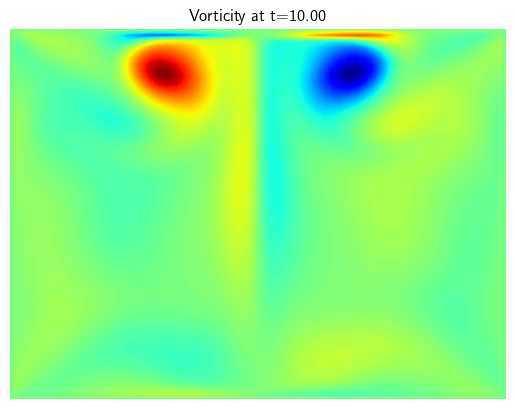

In [4]:
def forcing_function(time, point):
    time_decay = np.maximum(2.0 - 0.5 * time, 0.0)
    forced_value = (time_decay * np.where((point[0] > 0.4) & (point[0] < 0.6) & (point[1] > 0.1) & (point[1] < 0.3),
                     np.array([0.0, 1.0]),np.array([0.0, 0.0]) ) )
    return forced_value
    
DOMAIN_SIZE         = 1.0
N_POINTS            = 64
N_TIME_STEPS        = 100
TIME_STEP_LENGTH    = 0.1
KINEMATIC_VISCOSITY = 0.0001
MAX_ITER_CG         = None
element_length = DOMAIN_SIZE / (N_POINTS - 1)
scalar_shape   = (N_POINTS, N_POINTS)
scalar_dof     = N_POINTS ** 2
vector_shape   = (N_POINTS, N_POINTS, 2)
vector_dof     = N_POINTS ** 2 * 2

x    = np.linspace(0.0, DOMAIN_SIZE, N_POINTS)
y    = np.linspace(0.0, DOMAIN_SIZE, N_POINTS)
X, Y = np.meshgrid(x, y, indexing="ij")  # Using "ij" indexing makes the differential operators more logical.
coordinates = np.concatenate((X[..., np.newaxis], Y[..., np.newaxis]), axis=-1)
forcing_function_vectorized = np.vectorize(pyfunc=forcing_function,signature="(),(d)->(d)",)

plt.figure(figsize=(5, 5), dpi=160)

velocities_prev = np.zeros(vector_shape)
time_current = 0.0
    
for i in range(N_TIME_STEPS):
    time_current += TIME_STEP_LENGTH
    forces = forcing_function_vectorized(time_current, coordinates)

    # (1) Apply Forces
    velocities_forces_applied = velocities_prev + TIME_STEP_LENGTH * forces

    # (2) Nonlinear convection (=self-advection)
    velocities_advected = advect(velocities_forces_applied, velocities_forces_applied)

    # (3) Diffuse
    velocities_diffused = sc.sparse.linalg.cg(
                          A=sc.sparse.linalg.LinearOperator(shape=(vector_dof, vector_dof), matvec=diffusion_operator),
                          b=velocities_advected.flatten(),
                          maxiter=MAX_ITER_CG, )[0].reshape(vector_shape)

    # (4.1) Compute a pressure correction
    pressure = sc.sparse.linalg.cg(
            A=sc.sparse.linalg.LinearOperator(shape=(scalar_dof, scalar_dof), matvec=poisson_operator),
            b=divergence(velocities_diffused).flatten(),
            maxiter=MAX_ITER_CG, )[0].reshape(scalar_shape)

    # (4.2) Correct the velocities to be incompressible
    velocities_projected = velocities_diffused - gradient(pressure)

    # Advance to next time step
    velocities_prev = velocities_projected

    curl = curl_2d(velocities_projected)
    plt.contourf(X, Y, curl, cmap='jet', levels=100)
    #plt.quiver(X, Y, velocities_projected[..., 0], velocities_projected[..., 1], color="dimgray")

    clear_output(wait=True) 
    plt.title(f'Vorticity at t={time_current:.2f}')
    plt.axis('off')
    plt.show()

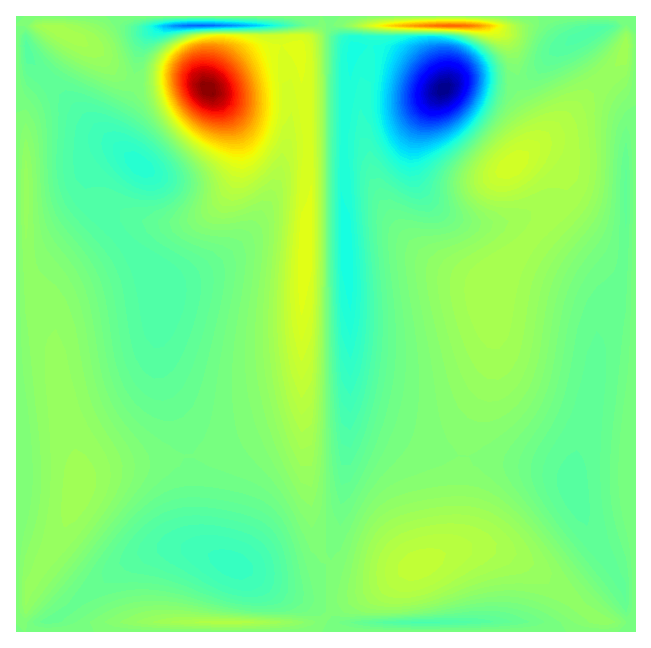

In [5]:
curl_frames = []

velocities_prev = np.zeros(vector_shape)
time_current = 0.0

for i in range(N_TIME_STEPS):
    time_current += TIME_STEP_LENGTH
    forces = forcing_function_vectorized(time_current, coordinates)

    velocities_forces_applied = velocities_prev + TIME_STEP_LENGTH * forces
    velocities_advected = advect(velocities_forces_applied, velocities_forces_applied)

    velocities_diffused = sc.sparse.linalg.cg(
        A=sc.sparse.linalg.LinearOperator(shape=(vector_dof, vector_dof), matvec=diffusion_operator),
        b=velocities_advected.flatten(), maxiter=MAX_ITER_CG,)[0].reshape(vector_shape)

    pressure = sc.sparse.linalg.cg(
        A=sc.sparse.linalg.LinearOperator(shape=(scalar_dof, scalar_dof), matvec=poisson_operator),
        b=divergence(velocities_diffused).flatten(), maxiter=MAX_ITER_CG,)[0].reshape(scalar_shape)

    velocities_projected = velocities_diffused - gradient(pressure)
    velocities_prev = velocities_projected

    curl = curl_2d(velocities_projected)
    curl_frames.append(curl.copy())  # store current frame


fig, ax = plt.subplots(figsize=(5, 5), dpi=160)
ax.set_axis_off()

frames = []
for curl in curl_frames:
    cont = ax.contourf(X, Y, curl, cmap='jet', levels=100)
    frames.append(cont.collections)

ani = animation.ArtistAnimation(fig, frames, interval=100, blit=True)

# Save as .gif using Pillow
ani.save("A vertical jet force vorticity.gif", writer='pillow', fps=10)
HTML('<img src="A vertical jet force vorticity.gif" width="600">')

A vertical jet of fluid emerging from a slot-like source on the bottom of a fluid tank, which shuts off after a short time

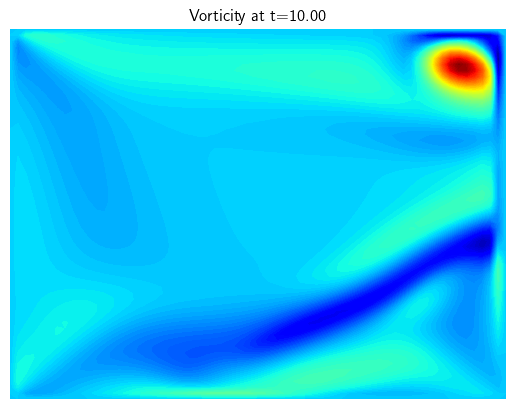

In [4]:
def forcing_function(time, point):
    time_decay = np.maximum(2.0 - 0.5 * time, 0.0)
    return time_decay * np.where((point[0] > 0.4) & (point[0] < 0.6) & (point[1] > 0.1) & (point[1] < 0.3),1.0, 0.0)

DOMAIN_SIZE         = 1.0
N_POINTS            = 64
N_TIME_STEPS        = 100
TIME_STEP_LENGTH    = 0.1
KINEMATIC_VISCOSITY = 0.0001
MAX_ITER_CG         = None
element_length = DOMAIN_SIZE / (N_POINTS - 1)
scalar_shape   = (N_POINTS, N_POINTS)
scalar_dof     = N_POINTS ** 2
vector_shape   = (N_POINTS, N_POINTS, 2)
vector_dof     = N_POINTS ** 2 * 2

# Grid creation
x = np.linspace(0.0, DOMAIN_SIZE, N_POINTS)
y = np.linspace(0.0, DOMAIN_SIZE, N_POINTS)
X, Y = np.meshgrid(x, y, indexing="ij")
coordinates = np.concatenate((X[..., np.newaxis], Y[..., np.newaxis]), axis=-1)
forcing_function_vectorized = np.vectorize(pyfunc=forcing_function,signature="(),(d)->(d)",)

# Initialize velocities
velocities_prev = np.zeros(vector_shape)
time_current = 0.0

plt.figure(figsize=(5, 5), dpi=160)

for i in range(N_TIME_STEPS):
    time_current += TIME_STEP_LENGTH
    forces = forcing_function(time_current, (X, Y))

    # Apply Forces
    velocities_forces_applied = velocities_prev + TIME_STEP_LENGTH * forces[..., np.newaxis]

    # Nonlinear convection
    velocities_advected = advect(velocities_forces_applied, velocities_forces_applied)

    # Diffuse
    velocities_diffused = sc.sparse.linalg.cg(
        A=sc.sparse.linalg.LinearOperator(shape=(vector_dof, vector_dof), matvec=diffusion_operator),
        b=velocities_advected.flatten(),maxiter=MAX_ITER_CG,)[0].reshape(vector_shape)

    # Pressure correction
    pressure = sc.sparse.linalg.cg(
        A=sc.sparse.linalg.LinearOperator(shape=(scalar_dof, scalar_dof), matvec=poisson_operator),
        b=divergence(velocities_diffused).flatten(),maxiter=MAX_ITER_CG,)[0].reshape(scalar_shape)

    # Correct velocities
    velocities_projected = velocities_diffused - gradient(pressure)

    # Advance to next time step
    velocities_prev = velocities_projected
    
    # Plotting
    clear_output(wait=True)
    plt.contourf(X, Y, curl_2d(velocities_projected), cmap='jet', levels=100)
    #plt.quiver(X, Y, velocities_projected[..., 0], velocities_projected[..., 1], color="dimgray")
    plt.title(f'Vorticity at t={time_current:.2f}')
    plt.axis('off')
    plt.show()

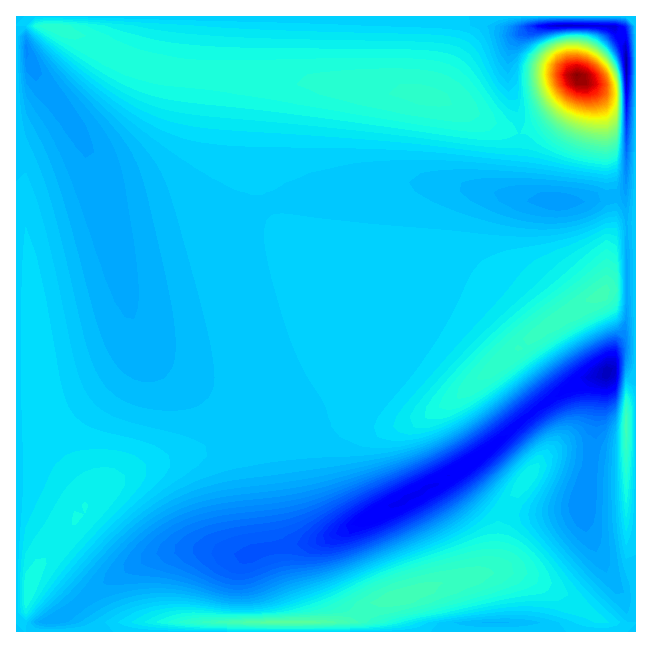

In [6]:
curl_frames = []
velocities_prev = np.zeros(vector_shape)
time_current = 0.0

for i in range(N_TIME_STEPS):
    time_current += TIME_STEP_LENGTH

    forces = forcing_function(time_current, (X, Y))

    # Apply Forces
    velocities_forces_applied = velocities_prev + TIME_STEP_LENGTH * forces[..., np.newaxis]

    # Advection
    velocities_advected = advect(velocities_forces_applied,velocities_forces_applied)

    # Diffusion
    velocities_diffused = sc.sparse.linalg.cg(
        A=sc.sparse.linalg.LinearOperator(shape=(vector_dof, vector_dof),matvec=diffusion_operator),
        b=velocities_advected.flatten(),maxiter=MAX_ITER_CG,)[0].reshape(vector_shape)

    # Pressure solve
    pressure = sc.sparse.linalg.cg(
        A=sc.sparse.linalg.LinearOperator(shape=(scalar_dof, scalar_dof),matvec=poisson_operator),
        b=divergence(velocities_diffused).flatten(),maxiter=MAX_ITER_CG,)[0].reshape(scalar_shape)

    # Projection
    velocities_projected = velocities_diffused - gradient(pressure)
    velocities_prev = velocities_projected

    # store curl
    curl_frames.append(curl_2d(velocities_projected).copy())


fig, ax = plt.subplots(figsize=(5, 5), dpi=160)
ax.set_axis_off()

frames = []
for curl in curl_frames:
    cont = ax.contourf(X, Y, curl, cmap='jet', levels=100)
    frames.append(cont.collections)
 
ani = animation.ArtistAnimation(fig, frames, interval=100, blit=True)
ani.save("jet_forced_vorticity.gif", writer="pillow", fps=10)
HTML('<img src="jet_forced_vorticity.gif" width="600">')

# FFT Method

### Burgers Equation

$\qquad\displaystyle \partial_t u + u\partial_x u = \nu\partial_{x}^2u$                                                                            
$\qquad\qquad\qquad\qquad\quad \partial_t u + \partial_x \frac{u^2}{2} = \nu\partial_{x}^2u$                                                           
$\quad \displaystyle {\frac{d}{dt} \hat{u}_k=-i\frac{k}{2} \hat{u^2}-\nu k^2 \hat{u}_k=-\hat{N}_k -\nu k^2 \hat{u}_k}  $                                
$\quad \displaystyle { \hat{u}_k^{n+1} = \hat{u}_k^n [1-\nu k (\Delta t)]- (\Delta t)\hat{N}_k }$                                                                
$\qquad\displaystyle{N_k = i k_x \mathrm{RFFT([IRFFT(f_k, N)*N]^2,N)/N}}$

In [64]:
def compute_Nk(fk,kx,N):
    f = np.fft.irfft(fk, N) * N  
    fk_prod = np.fft.rfft(f**2, N) / N  
    return 1j * kx * fk_prod

#### Euler's explicit scheme                                                                                                                            
$\quad \displaystyle {\frac{d}{dt} \hat{u}_k=-i\frac{k}{2} \hat{u^2}-\nu k^2 \hat{u}_k=-\hat{N}_k -\nu k^2 \hat{u}_k}  $                                
$\quad \displaystyle { \hat{u}_k'= \hat{u}_k\exp(\nu k^2 t)}$   
$\quad \displaystyle {\frac{d}{dt} \hat{u}_k'= -\hat{N}_k\exp(\nu k^2 t)}$                                                                        
$\quad \displaystyle { \hat{u}_k^{n+1} = [\hat{u}_k^n - (\Delta t)\hat{N}_k^n]\exp(\nu k^2 t) }$   

where $\quad \displaystyle \hat{N}_k = i\frac{k}{2}\widehat{u^2}$ nonlinear term treated explicitly, linear term implicitly                                  
We simulate the Burgers equation in $x = [0,2π]$ with $\nu= 0.1$ up to final time of $1$ unit.                                                       
We start with an initial state of $\sin(x)$, and choose $Δt = 0.001$ for time stepping.                                                  

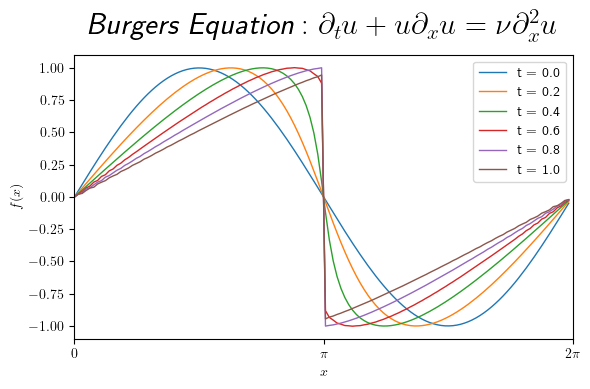

In [65]:
nu = 0.1e-6
tf = 1           
dt = 0.001         
nsteps = int(tf / dt)  
L = 2 * np.pi      
N = 129          
h = L / N          
j = np.arange(0, N)
x = j * h          
kx = np.fft.rfftfreq(N, d=h) * (2 * np.pi)  

fig, ax1 = plt.subplots(figsize=(6, 4))

f = np.sin(x)  
fk = np.fft.rfft(f, N) / N  
for i in range(nsteps + 1):
    Nk = compute_Nk(fk,kx,N)  
    fk = (fk - dt * Nk) * np.exp( nu * (kx)**2 * (i * dt))      # i*dt=t
    if i % 200 == 0:
        t = i * dt
        f_plot = np.fft.irfft(fk, N) * N 
        ax1.plot( x, f_plot, lw=1, label=f't = {t:.1f}')
ax1.set_xlim(0, 2 * np.pi)
ax1.set_xlabel('$x$', fontsize=10)
ax1.set_ylabel('$f(x)$', fontsize=10)
ax1.set_xticks([0, np.pi, 2 * np.pi])
ax1.set_xticklabels(['$0$', '$\pi$', '$2\pi$'])
plt.title(r'$\textit{Burgers Equation}: \partial_t u + u \partial_x u = \nu \partial_{x}^2 u$', fontsize=22, y=1.041)
plt.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()

#### RK2 scheme                                                                                                                                     
We simulate the Burgers equation in $x = [0,2π]$ with $\nu= 0.1$ up to final time of $1$ unit.                                                       
We start with an initial state of $\sin(x)$, and choose $Δt = 0.001$ for time stepping.                                                              
We employ the exponential trick, and time advance the nonlinear term using **RK2** method.

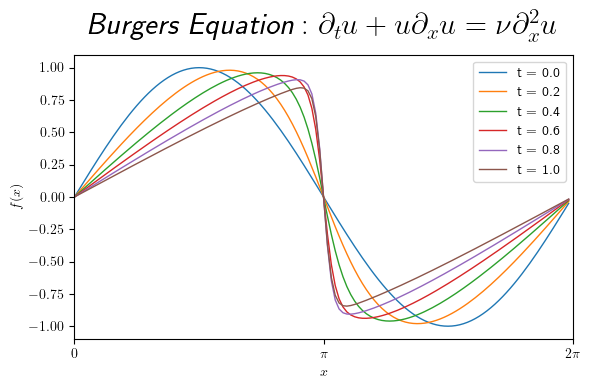

In [66]:
nu = 0.1           
tf = 1.0          
dt = 0.001        
nsteps = int(tf / dt)  
L = 2 * np.pi    
N = 128         
h = L / N        
j = np.arange(0, N)
x = j * h       
kx = np.fft.rfftfreq(N, d=h) * (2 * np.pi)  

fig, ax1 = plt.subplots(figsize=(6, 4))

f = np.sin(x) 
fk = np.fft.rfft(f, N) / N
for i in range(nsteps + 1):
    Nk = compute_Nk(fk,kx,N)  
    fk_mid = (fk - (dt / 2) * Nk) * np.exp(-nu * kx**2 * dt / 2)
    Nk_mid = compute_Nk(fk_mid,kx,N) 
    fk = (fk - dt * Nk_mid) * np.exp(-nu * kx**2 * dt) 
    if i % 200 == 0:
        t = i * dt
        f_plot = np.fft.irfft(fk, N) * N 
        ax1.plot(x, f_plot, lw=1, label=f't = {t:.1f}')
ax1.set_xlim(0, 2 * np.pi)
ax1.set_xlabel('$x$', fontsize=10)
ax1.set_ylabel('$f(x)$', fontsize=10)
ax1.set_xticks([0, np.pi, 2 * np.pi])
ax1.set_xticklabels(['$0$', '$\pi$', '$2\pi$'])
plt.title(r'$\textit{Burgers Equation}: \partial_t u + u \partial_x u = \nu \partial_{x}^2 u$', fontsize=22, y=1.041)
plt.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()

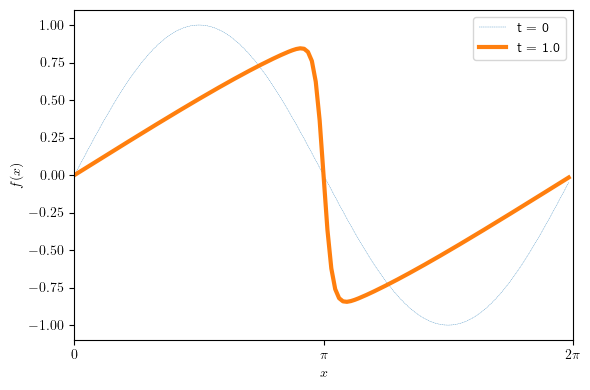

In [67]:
nu = 0.1           
tf = 1.0          
dt = 0.001        
nsteps = int(tf / dt)  
L = 2 * np.pi    
N = 128         
h = L / N        
j = np.arange(0, N)
x = j * h       
kx = np.fft.rfftfreq(N, d=h) * (2 * np.pi)  


f = np.sin(x) 
fk = np.fft.rfft(f, N) / N
for i in range(nsteps + 1):
    Nk = compute_Nk(fk,kx,N)  
    fk_mid = (fk - (dt / 2) * Nk) * np.exp(-nu * kx**2 * dt / 2)
    Nk_mid = compute_Nk(fk_mid,kx,N) 
    fk = (fk - dt * Nk_mid) * np.exp(-nu * kx**2 * dt) 
    if i % 200 == 0:
        t = i * dt
        f_plot = np.fft.irfft(fk, N) * N 
        
        clear_output(wait=True)
        fig, ax1 = plt.subplots(figsize=(6, 4))
        ax1.plot( x, f, '--', lw=0.25, label=f't = 0')
        ax1.plot( x, f_plot, lw=3, label=f't = {t:.1f}')
        ax1.set_xlim(0, 2 * np.pi)
        ax1.set_xlabel('$x$', fontsize=10)
        ax1.set_ylabel('$f(x)$', fontsize=10)
        ax1.set_xticks([0, np.pi, 2 * np.pi])
        ax1.set_xticklabels(['$0$', '$\pi$', '$2\pi$'])
        plt.legend(loc='upper right', fontsize=10)
        plt.tight_layout()
        plt.show()

 #### Crank-Nicolson scheme                                                                                                                                              
                                                                                                                                            
$\quad \displaystyle { \hat{u}_k^{n+1} = \hat{u}_k^n - \nu k^2 \frac{(\Delta t)}{2} \big( \hat{u}_k^n + \hat{u}_k^{n+1} \big) - (\Delta t)\hat{N}_k }$           
$\quad \displaystyle{\hat{u}_k^{n+1} = \hat{u}_k^n - \nu k^2 \frac{(\Delta t)}{2} \hat{u}_k^n - \nu k^2 \frac{(\Delta t)}{2} \hat{u}_k^{n+1} - (\Delta t)\hat{N}_k }$                                                                                                                                                           
$\quad \displaystyle { \hat{u}_k^{n+1} + \nu k^2 \frac{(\Delta t)}{2} \hat{u}_k^{n+1} = \hat{u}_k^n - \nu k^2 \frac{(\Delta t)}{2} \hat{u}_k^n - (\Delta t)\hat{N}_k }$                                                                                                                                           
$\quad \displaystyle { \hat{u}_k^{n+1}\bigg[1 + \nu k^2 \frac{(\Delta t)}{2} \bigg] = \hat{u}_k^n\bigg[1 - \nu k^2 \frac{(\Delta t)}{2}\bigg] - (\Delta t)\hat{N}_k }$                                                                                                                                            
$\quad \displaystyle { \hat{u}_k^{n+1} = \frac{ \hat{u}_k^n\bigg[1 - \nu k^2 \frac{(\Delta t)}{2}\bigg] - (\Delta t)\hat{N}_k } { \bigg[1 + \nu k^2 \frac{(\Delta t)}{2} \bigg] } }$                                                                                                                                                                                                                                                                                                     
since $ \quad \displaystyle \frac{1}{1+\nu k^2 (\Delta t)/2} \approx 1 $          


$\quad \displaystyle { \hat{u}_k^{n+1} = \hat{u}_k^n \bigg[ \frac{1-\nu k^2 (\Delta t)/2}{1+\nu k^2 (\Delta t)/2} \bigg]- (\Delta t)\hat{N}_k }$                                                        
where $\quad \displaystyle \hat{N}_k = i\frac{k}{2}\widehat{u^2}$ nonlinear term treated explicitly, linear term implicitly

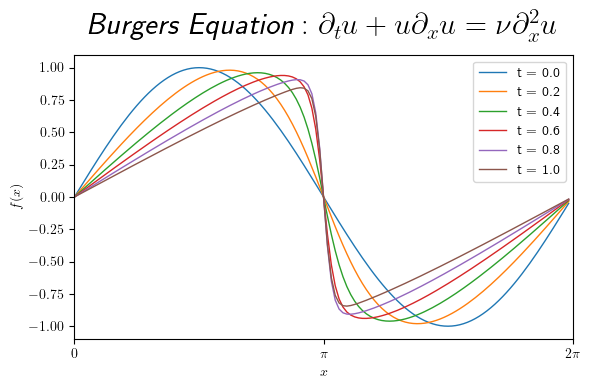

In [68]:
nu = 0.1          
tf = 1.0          
dt = 0.001        
nsteps = int(tf / dt) 
L = 2 * np.pi     
N = 128        
h = L / N          
j = np.arange(0, N)
x = j * h          
kx = np.fft.rfftfreq(N, d=h) * (2 * np.pi)  

fig, ax1 = plt.subplots(figsize=(6, 4))

f = np.sin(x)  
fk = np.fft.rfft(f, N) / N 
for i in range(nsteps + 1):
    Nk = compute_Nk(fk, kx, N)  
    fk_new = ( fk * (1 - nu * kx**2 * dt / 2)  - dt * Nk  ) / (1 + nu * kx**2 * dt / 2) 
    fk = fk_new
    if i % 200 == 0:
        t = i * dt
        f_plot = np.fft.irfft(fk, N) * N  # Convert back to physical space
        ax1.plot(x, f_plot, '-', lw=1, label=f't = {t:.1f}')

ax1.set_xlim(0, 2 * np.pi)
ax1.set_xlabel('$x$', fontsize=10)
ax1.set_ylabel('$f(x)$', fontsize=10)
ax1.set_xticks([0, np.pi, 2 * np.pi])
ax1.set_xticklabels(['$0$', '$\pi$', '$2\pi$'])
plt.title(r'$\textit{Burgers Equation}: \partial_t u + u \partial_x u = \nu \partial_{x}^2 u$', fontsize=22, y=1.041)
plt.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()

### KdV Equation

$ \qquad\qquad\displaystyle \partial_t u + u\partial_x u = \kappa\partial_{x}^3u$


We simulate **KdV** equation for $\kappa = 0.1$ up to $2$ time unit. We take $dt = 0.001$.                                                                   
The initial condition is chosen as $\sin(x)$.                                                                                        

##### Euler’s explicit scheme 

$\quad \displaystyle \frac{d}{dt}\hat{u}_k= -\,i\frac{k}{2}\widehat{u^2} - i\,\kappa k^3 \hat{u}_k = -\hat{N}_k - i\,\kappa k^3 \hat{u}_k$

$\quad \displaystyle \hat{u}_k' = \hat{u}_k \exp\!\left(-i\,\kappa k^3 t\right)$

$\quad \displaystyle \frac{d}{dt}\hat{u}_k' = -\hat{N}_k \exp\!\left(-i\,\kappa k^3 t\right)$

$\quad \displaystyle\hat{u}_k^{n+1} =\left[\hat{u}_k^{n} - (\Delta t)\,\hat{N}_k^{n}\right] \exp\!\left(-i\,\kappa k^3 \Delta t\right)$

where $\quad \displaystyle \hat{N}_k = i\frac{k}{2}\widehat{u^2}$ nonlinear term treated explicitly, linear term implicitly

We employ exponential trick for absorbing the diffusion term, and time advance the nonlinear term using leapfrog method.     
At t = 2, we observe several solitons, which are stable hump-like structures.

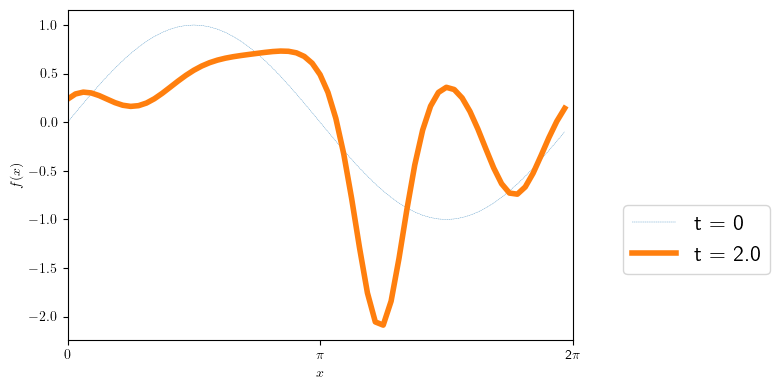

In [69]:
kappa = 0.1
tf = 2
dt = 0.001
nsteps = int(tf/dt)
L = 2*np.pi
N = 64
h = L/N
j = np.arange(0,N)
x = j*h
kx = np.linspace(0, N//2, N//2+1)

f = np.sin(x)
fk = np.fft.rfft(f,N)/N
prev = fk                       
Nk = compute_Nk(fk,kx,N)
curr = (prev - dt*Nk)*np.exp(-1j*kappa*kx**3*dt)
for i in range(nsteps+2):
    Nk = compute_Nk(curr,kx,N)
    fk = (prev - dt*Nk)*np.exp(-1j*kappa*kx**3*dt)
    if (i%400 == 0):
        t = i*dt
        fr = np.fft.irfft(fk,N)*N
        clear_output(wait=True)
        fig, ax1 = plt.subplots(figsize=(6, 4))
        ax1.plot( x, f, '--', lw=0.25, label=f't = 0')
        ax1.plot(x, fr, lw = 4, label=f't = {t:.1f}')
        ax1.set_xlim(0,2*np.pi)
        ax1.set_xlabel('$x$',fontsize=10)
        ax1.set_ylabel('$f(x)$',fontsize=10)
        ax1.set_xticks([0, np.pi, 2*np.pi])
        ax1.set_xticklabels(['$0$', '$\pi$', '2$\pi$'])
        plt.tight_layout()
        plt.legend(loc=(1.1, 0.2), fontsize=16)
        plt.show()
    prev = curr
    curr = fk

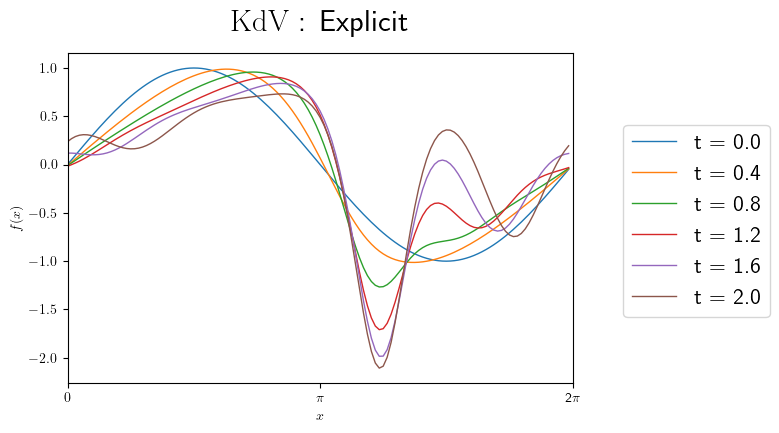

In [70]:
kappa = 0.1
tf = 2
dt = 0.001
nsteps = int(tf/dt)
L = 2*np.pi
N = 128
h = L/N
j = np.arange(0,N)
x = j*h
kx = np.linspace(0, N//2, N//2+1)

fig, ax1 = plt.subplots(figsize=(6, 4))

f = np.sin(x)
fk = np.fft.rfft(f,N)/N
prev = fk                       
Nk = compute_Nk(fk,kx,N)
curr = (prev - dt*Nk)*np.exp(-1j*kappa*kx**3*dt)
for i in range(nsteps+2):
    Nk = compute_Nk(curr,kx,N)
    fk = (prev - dt*Nk)*np.exp(-1j*kappa*kx**3*dt)
    if (i%400 == 0):
        t = i*dt
        f = np.fft.irfft(fk,N)*N
        ax1.plot(x, f, lw = 1, label=f't = {t:.1f}')
    prev = curr
    curr = fk
ax1.set_xlim(0,2*np.pi)
ax1.set_xlabel('$x$',fontsize=10)
ax1.set_ylabel('$f(x)$',fontsize=10)
ax1.set_xticks([0, np.pi, 2*np.pi])
ax1.set_xticklabels(['$0$', '$\pi$', '2$\pi$'])
plt.tight_layout()
plt.title(r'$\mathrm{KdV}$ : Explicit', fontsize=22,y=1.041)
plt.legend(loc=(1.1, 0.2), fontsize=16)
plt.show()

#### RK2 (midpoint) scheme

**Step 1 (half step)**

$\quad \displaystyle  \hat{u}_k^{*}=\left(\hat{u}_k^n - \frac{\Delta t}{2}\hat{N}_k^n\right)\exp\!\left(-i\,\kappa k^3 \frac{\Delta t}{2}\right)$

**Step 2 (full step)**

$\quad \displaystyle \hat{u}_k^{n+1}=\left(\hat{u}_k^n - \Delta t\,\hat{N}_k^{*}\right)\exp\!\left(-i\,\kappa k^3 \Delta t\right)$

where

$\quad \displaystyle \hat{N}_k = i\frac{k}{2}\widehat{u^2}$

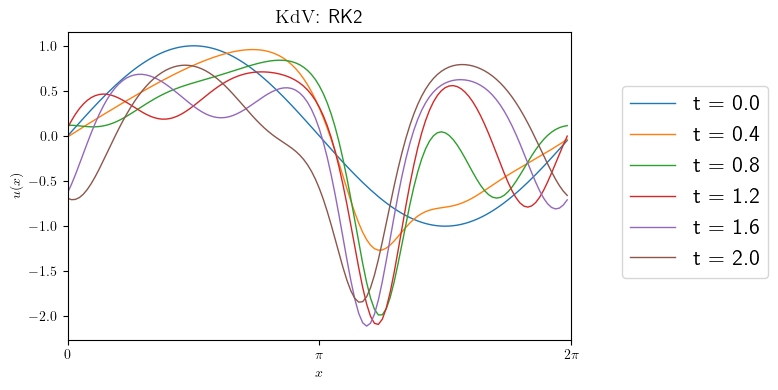

In [71]:
kappa = 0.1
tf = 2.0
dt = 0.001
nsteps = int(tf / dt)
L = 2 * np.pi
N = 128
h = L / N
x = np.linspace(0, L, N, endpoint=False)
kx = np.fft.rfftfreq(N, d=h) * 2 * np.pi
f = np.sin(x)
fk = np.fft.rfft(f, N) / N
 
fig, ax = plt.subplots(figsize=(8, 4))
 
for i in range(nsteps + 1):
    Nk = compute_Nk(fk, kx, N)
    fk_mid = (fk - (dt/2) * Nk) * np.exp(-1j * kappa * kx**3 * dt/2)
    Nk_mid = compute_Nk(fk_mid, kx, N)
    fk = (fk - dt * Nk_mid) * np.exp(-1j * kappa * kx**3 * dt)
    if i % 400 == 0:
        t = i * dt
        f_plot = np.fft.irfft(fk, N) * N
        ax.plot(x, f_plot, lw=1, label=f't = {t:.1f}')
ax.set_xlim(0, 2*np.pi)
ax.set_xlabel('$x$', fontsize=10)
ax.set_ylabel('$u(x)$', fontsize=10)
ax.set_xticks([0, np.pi, 2*np.pi])
ax.set_xticklabels(['$0$', '$\\pi$', '$2\\pi$'])
plt.title(r'$\mathrm{KdV}$: RK2', fontsize=14)
plt.legend(loc=(1.1, 0.2), fontsize=16)
plt.tight_layout()
plt.show()

##### Crank–Nicolson scheme

$\quad \displaystyle \frac{d}{dt}\hat{u}_k= -\,i\frac{k}{2}\widehat{u^2} + i\,\kappa k^3 \hat{u}_k = -\hat{N}_k + i\,\kappa k^3 \hat{u}_k$

$\quad \displaystyle \frac{\hat{u}_k^{n+1}-\hat{u}_k^{n}}{\Delta t}=-\hat{N}_k^{n} + \frac{i\,\kappa k^3}{2}\left(\hat{u}_k^{n+1}+\hat{u}_k^{n}\right)$

$\quad \displaystyle \left(1 - \frac{i\,\kappa k^3 \Delta t}{2}\right)\hat{u}_k^{n+1}=\left(1 + \frac{i\,\kappa k^3 \Delta t}{2}\right)\hat{u}_k^{n} - \Delta t\,\hat{N}_k^{n}$

$\quad \displaystyle\hat{u}_k^{n+1}=\frac{\left(1 + \frac{i\,\kappa k^3 \Delta t}{2}\right)\hat{u}_k^{n} - \Delta t\,\hat{N}_k^{n}}{1 - \frac{i\,\kappa k^3 \Delta t}{2}}$

where $\quad \displaystyle \hat{N}_k = i\frac{k}{2}\widehat{u^2}$ nonlinear term treated explicitly, linear term implicitly

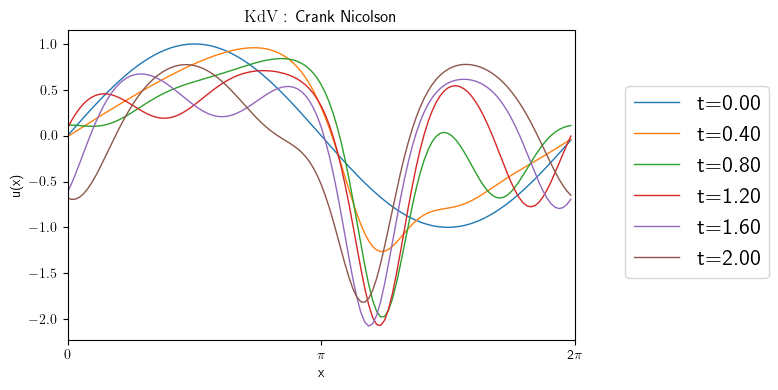

In [72]:
kappa = 0.1
tf = 2.0
dt = 0.001
nsteps = int(tf/dt)
L = 2*np.pi
N = 128
dx = L/N
x = np.linspace(0, L, N, endpoint=False)
kx = np.fft.rfftfreq(N, d=dx) * 2*np.pi
ik3 = (1j * kx)**3
u = np.sin(x)
fk = np.fft.rfft(u, N) / N   # normalized
plt.figure(figsize=(8,4))
for n in range(nsteps+2):
    Nk = compute_Nk(fk, kx, N)
    LHS = 1 - 0.5 * dt * kappa * ik3
    RHS = (1 + 0.5 * dt * kappa * ik3) * fk - dt * Nk
    fk = RHS / LHS
    if n % 400 == 0:
        u = np.fft.irfft(fk, N) * N
        plt.plot(x, u, lw=1, label=f"t={n*dt:.2f}")

plt.xlim(0, 2*np.pi)
plt.xlabel("x")
plt.ylabel("u(x)")
plt.title(r"$\mathrm{KdV}$ : Crank Nicolson")
plt.xticks([0, np.pi, 2*np.pi],['$0$', '$\pi$', '2$\pi$'])
plt.legend(loc=(1.1, 0.2), fontsize=16)
plt.tight_layout()
plt.show()

### Navier-Strokes Eqn.                                                                                                                                    
$\textit{From Burgers Equation} : \partial_t u + u\partial_x u = \nu\partial_{x}^2u$                                                                           
This is generalized to the **Navier–Stokes equations**,
                                                                                         
$\qquad\displaystyle \partial_t u + u\nabla u = -\nabla p + \nu\nabla^2 u$                                                                                                 
$\qquad\displaystyle\nabla\cdot u=0$                                                                                                                                         
The velocity field is transformed to Fourier space,                                                                                                      
$\qquad \displaystyle \frac{d}{dt}\hat{u}_{k,i} = -ik_j\widehat{u_ju_i}_k -ik_i\hat{p}_k-\nu k^2\hat{u}_{k,i}=-\hat{N}_{k,i} -ik_i\hat{p}_k-\nu k^2\hat{u}_{k,i} $                                                                                                                                                                                                                                                                              
With the incompressibility condition, $ \ \displaystyle k_i \hat{u}_{k,i}=0$                                        

$\qquad\displaystyle \hat{u}_{k,i} \ \underrightarrow{IFFT} \ u_i(r) \ \underrightarrow{\text{Mult }} \ u_j(r)u_i(r) \ \underrightarrow{FFt} \ \widehat{(u_j u_i)}_k \ \underrightarrow{\text{Mult }ik_j} \ ik_j\widehat{(u_j u_i)}_k$                                                                                              
The pressure $p$ is determined by solving, $\qquad\displaystyle -\nabla^2 p=\nabla\cdot[u\cdot\nabla u]=\nabla\cdot N$                                                                               
In Fourier space, $\qquad\displaystyle \hat{p}_k=i\frac{1}{k}k\cdot\hat{N}_k$                                                                                                     
From Time-stepping Forward Euler , $\qquad\displaystyle \hat{u}_k^{n+1} = \hat{u}_k^{n}\left[ 1-\nu k^2(\Delta t) \right]  + (\Delta t)\left[-\hat{N}_k - ik\hat{p}_k^n\right]$

#### 2D 

Solve the **incompressible Navier–Stokes equations** in a 2D periodic domain of size $(2\pi)^2$:

$\qquad\qquad\displaystyle\frac{\partial \mathbf{u}}{\partial t} + \mathbf{u} \cdot \nabla \mathbf{u} = -\nabla p + \nu \nabla^2 \mathbf{u}, \quad \nabla \cdot \mathbf{u} = 0$

Let the initial velocity field be given by the **Taylor–Green vortex**:

$\qquad\qquad\displaystyle \left\{\begin{array}{rl} u_x(x, y) &= \quad \sin(x) \cos(y), \\ u_y(x, y) &= -\cos(x) \sin(y). \end{array} \right. $                                                                  

* Viscosity: $\nu = 0.1$
* Grid: $32 \times 32$
* Domain: $x, y \in [0, 2\pi)$
* Final time: $T = 1.0$
                                                                                                                                                            
Evolve the velocity field from $t = 0$ to $t = 1$ using a spectral method and visualize the evolution of the velocity magnitude or vorticity.

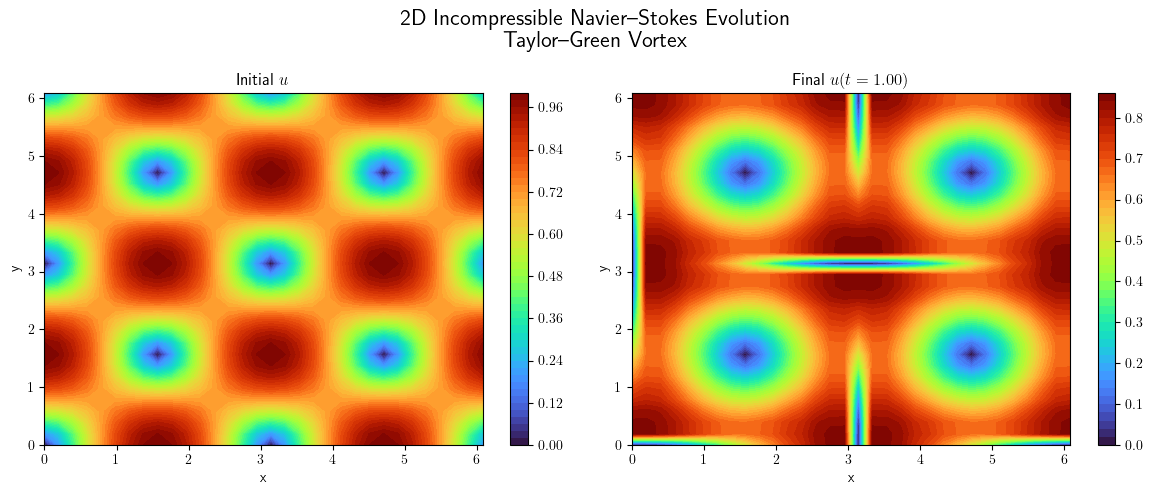

In [16]:
N      = 32
L      = 2 * np.pi
nu     = 0.1
T      = 1
dt     = 0.01
nsteps = int(T / dt)
x      = np.linspace(0, L, N, endpoint=False)
y      = x.copy()
X, Y   = np.meshgrid(x, y, indexing="ij")

# Wave numbers
kx       = np.fft.fftfreq(N, d=L / N) * 2 * np.pi
ky       = kx.copy()
KX, KY   = np.meshgrid(kx, ky, indexing="ij")
K2       = KX**2 + KY**2
K2[0, 0] = 1.0  # to avoid division by zero
invK2    = 1.0 / K2

# Initial condition: Taylor-Green vortex
u     =  np.sin(X) * np.cos(Y)
v     = -np.cos(X) * np.sin(Y)
u_hat = np.fft.fft2(u)
v_hat = np.fft.fft2(v)
speed_init = np.sqrt(u**2 + v**2)

def compute_nonlinear_terms(u_hat, v_hat):
    # Convert to real space
    u = np.fft.ifft2(u_hat).real
    v = np.fft.ifft2(v_hat).real

    # Compute derivatives
    ux = np.fft.ifft2(1j * KX * u_hat).real
    uy = np.fft.ifft2(1j * KY * u_hat).real
    vx = np.fft.ifft2(1j * KX * v_hat).real
    vy = np.fft.ifft2(1j * KY * v_hat).real

    # Compute convective (nonlinear) terms in real space
    N1 = u * ux + v * uy
    N2 = u * vx + v * vy
    return np.fft.fft2(N1), np.fft.fft2(N2) # Transform back to Fourier space

# Time loop
for step in range(nsteps + 1):
    N1_hat, N2_hat = compute_nonlinear_terms(u_hat, v_hat)

    # Pressure projection (make flow incompressible)
    div_hat = 1j * (KX * N1_hat + KY * N2_hat)
    p_hat = div_hat * invK2

    N1_hat -= 1j * KX * p_hat
    N2_hat -= 1j * KY * p_hat

    # Time integration (Euler step + diffusion)
    decay = np.exp(-nu * K2 * dt)
    u_hat = (u_hat - dt * N1_hat) * decay
    v_hat = (v_hat - dt * N2_hat) * decay

    # Plotting
    if step % 20 == 0 or step == nsteps:
        u_real = np.fft.ifft2(u_hat).real
        v_real = np.fft.ifft2(v_hat).real
        speed_now = np.sqrt(u_real**2 + v_real**2)

        fig, ax = plt.subplots(1, 2, figsize=(12, 5))

        c0 = ax[0].contourf(X, Y, speed_init, cmap='turbo', levels=50)
        #ax[0].quiver(X, Y, u_real, v_real, scale=40, color='k', alpha=0.5)
        fig.colorbar(c0, ax=ax[0])
        ax[0].set_title(r"Initial $u$")

        c1 = ax[1].contourf(X, Y, speed_now, cmap='turbo', levels=50)
        #ax[1].quiver(X, Y, u_real, v_real, scale=40, color='k', alpha=0.5)        
        fig.colorbar(c1, ax=ax[1])
        ax[1].set_title(f"Final $u  (t = {step*dt:.2f})$")

        for a in ax:
            a.set_xlabel("x")
            a.set_ylabel("y")

        plt.suptitle("2D Incompressible Navier–Stokes Evolution\nTaylor–Green Vortex", fontsize=16)
        plt.tight_layout()
        clear_output(wait=True)
        plt.show()

#### 3D

Solve the **incompressible Navier–Stokes equations** in a 3D periodic domain of size $(2\pi)^3$:

$\qquad\qquad\displaystyle\frac{\partial \mathbf{u}}{\partial t} + \mathbf{u} \cdot \nabla \mathbf{u} = -\nabla p + \nu \nabla^2 \mathbf{u}, \quad \nabla \cdot \mathbf{u} = 0$

Let the initial velocity field be given by the **Taylor–Green vortex**:

$\qquad\qquad\displaystyle \left\{\begin{array}{rl} u_x(x, y, z) = \cos(x)\sin(y)\sin(z), \\ u_y(x, y, z) = \sin(x) \cos(y) \sin(z), \\ u_z(x, y, z) = \sin(x) \sin(y) \cos(z). \end{array} \right. $                                                                 

* Viscosity: $\nu = 0.1$
* Grid: $32 \times 32 \times 32$
* Domain: $x, y, z \in [0, 2\pi)$
* Final time: $T = 1.0$
                                                                                                                                                            
Evolve the velocity field from $t = 0$ to $t = 1$ using a spectral method and visualize the evolution of the velocity magnitude or vorticity.

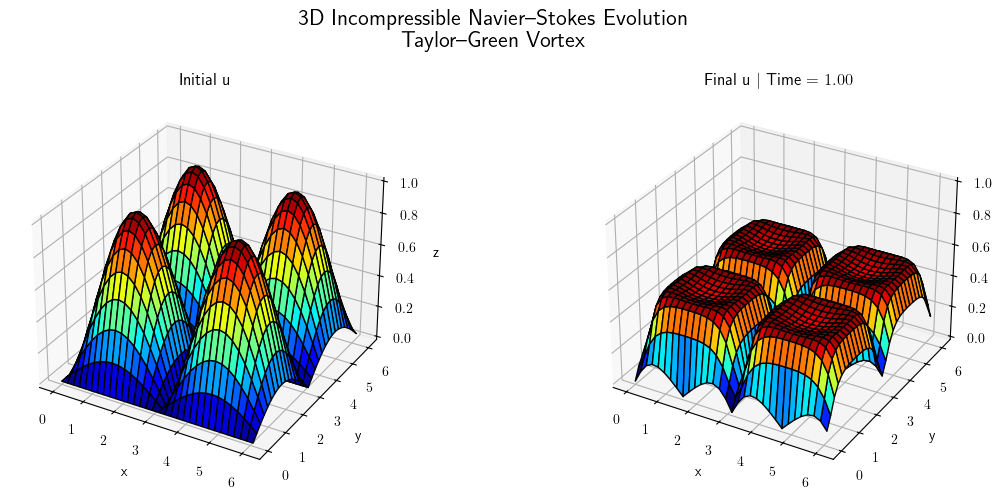

In [8]:
N       = 32
L       = 2 * np.pi
nu      = 0.1
T       = 1.0
dt      = 0.01
nsteps  = int(T / dt)
x       = np.linspace(0, L, N, endpoint=False)
X, Y, Z = np.meshgrid(x, x, x, indexing='ij')
idx     = N // 2  # z-slice index

# Wave numbers
kx          = np.fft.fftfreq(N, d=L/N) * 2 * np.pi
KX, KY, KZ  = np.meshgrid(kx, kx, kx, indexing='ij')
K2          = KX**2 + KY**2 + KZ**2
K2[0, 0, 0] = 1.0  # avoid division by zero
invK2       = 1.0 / K2

# Taylor-Green initial velocity
u     = np.cos(X) * np.sin(Y) * np.sin(Z)
v     = np.sin(X) * np.cos(Y) * np.sin(Z)
w     = np.sin(X) * np.sin(Y) * np.cos(Z)
u_hat = np.fft.fftn(u)
v_hat = np.fft.fftn(v)
w_hat = np.fft.fftn(w)
speed_init = np.sqrt(u**2 + v**2 + w**2)[:, :, idx]

# Nonlinear term function
def compute_nonlinear_terms(u_hat, v_hat, w_hat):
    u = np.fft.ifftn(u_hat).real
    v = np.fft.ifftn(v_hat).real
    w = np.fft.ifftn(w_hat).real

    ux = np.fft.ifftn(1j * KX * u_hat).real
    uy = np.fft.ifftn(1j * KY * u_hat).real
    uz = np.fft.ifftn(1j * KZ * u_hat).real

    vx = np.fft.ifftn(1j * KX * v_hat).real
    vy = np.fft.ifftn(1j * KY * v_hat).real
    vz = np.fft.ifftn(1j * KZ * v_hat).real

    wx = np.fft.ifftn(1j * KX * w_hat).real
    wy = np.fft.ifftn(1j * KY * w_hat).real
    wz = np.fft.ifftn(1j * KZ * w_hat).real

    N1 = u * ux + v * uy + w * uz
    N2 = u * vx + v * vy + w * vz
    N3 = u * wx + v * wy + w * wz

    return np.fft.fftn(N1), np.fft.fftn(N2), np.fft.fftn(N3)

# Time loop
for step in range(nsteps + 1):
    N1_hat, N2_hat, N3_hat = compute_nonlinear_terms(u_hat, v_hat, w_hat)

    # Pressure projection
    div_hat = 1j * (KX * N1_hat + KY * N2_hat + KZ * N3_hat)
    p_hat = div_hat * invK2

    N1_hat -= 1j * KX * p_hat
    N2_hat -= 1j * KY * p_hat
    N3_hat -= 1j * KZ * p_hat

    # Time stepping
    decay = np.exp(-nu * K2 * dt)
    u_hat = (u_hat - dt * N1_hat) * decay
    v_hat = (v_hat - dt * N2_hat) * decay
    w_hat = (w_hat - dt * N3_hat) * decay

    # Plot every 20 steps
    if step % 20 == 0 or step == nsteps:
        u_real = np.fft.ifftn(u_hat).real
        v_real = np.fft.ifftn(v_hat).real
        w_real = np.fft.ifftn(w_hat).real
        speed_now = np.sqrt(u_real**2 + v_real**2 + w_real**2)[:, :, idx]

        if step == nsteps:
            speed_final = speed_now.copy()

        # Setup figure
        fig, ax = plt.subplots(1, 2, figsize=(12, 5), subplot_kw={"projection": "3d"})
        surf0 = ax[0].plot_surface(X[:, :, idx], Y[:, :, idx], speed_init, cmap='jet', edgecolor='k')
        ax[0].set_title("Initial u")

        surf1 = ax[1].plot_surface(X[:, :, idx], Y[:, :, idx], speed_now, cmap='jet', edgecolor='k')
        ax[1].set_title(rf"Final u $|$ Time $= {step*dt:.2f}$")
        ax[1].set_zlim(0,1)
        
        for a in ax:
            a.set_xlabel("x")
            a.set_ylabel("y")
            a.set_zlabel("z")

        plt.suptitle("3D Incompressible Navier–Stokes Evolution\nTaylor–Green Vortex", fontsize=16)
        plt.tight_layout()
        clear_output(wait=True)
        plt.show()

#### 2D

Solve the **incompressible Navier–Stokes equations** in a 2D periodic domain of size $(1)^2$:

$\qquad\qquad\displaystyle\frac{\partial \mathbf{u}}{\partial t} + \mathbf{u} \cdot \nabla \mathbf{u} = -\nabla p + \nu \nabla^2 \mathbf{u}, \quad \nabla \cdot \mathbf{u} = 0$

Let the initial velocity field be given by the ** vortex**:

$\qquad\qquad\displaystyle \left\{\begin{array}{rl} u_x(x, y) &= \sin(2\pi y), \\ u_y(x, y) &= \cos(2\pi x^2). \end{array} \right. $                                                                  

* Viscosity: $\nu = 0.001$
* Grid: $128 \times 128$
* Domain: $x, y \in [0, 1)$
* Final time: $T = 1.0$
                                                                                                                                                            
Evolve the velocity field from $t = 0$ to $t = 1$ using a spectral method and visualize the evolution of the velocity magnitude or vorticity.

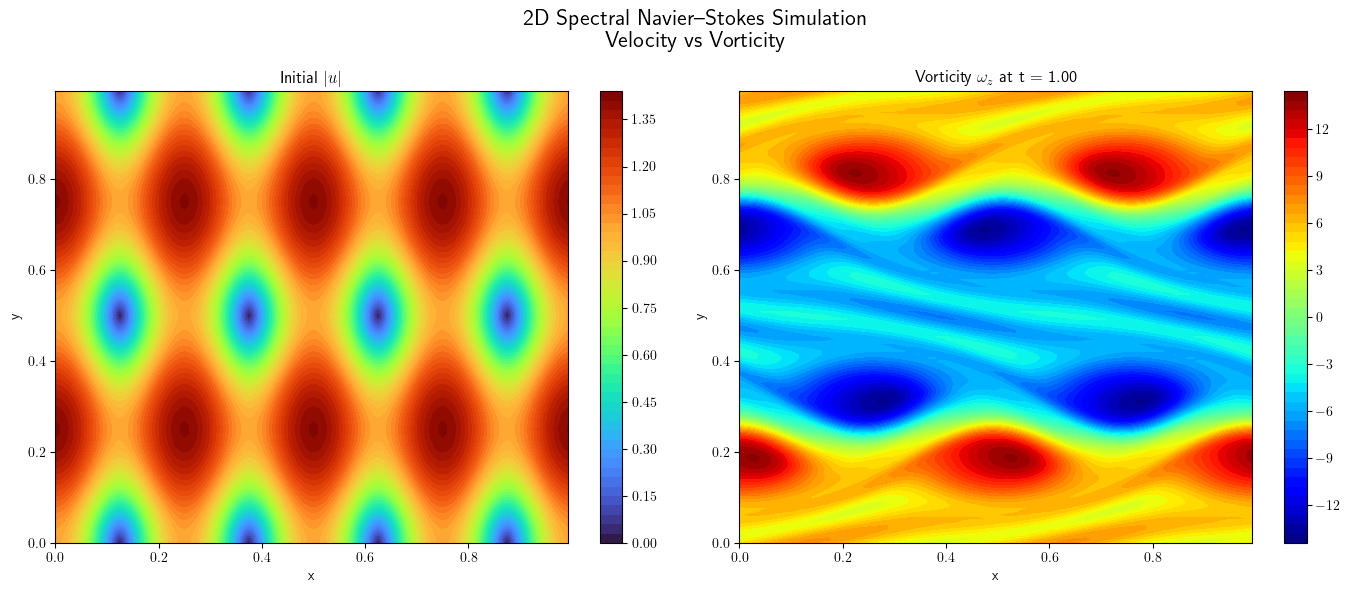

In [2]:
def grad(v):
    v_hat = np.fft.fftn(v)
    dvx = np.real(np.fft.ifftn(1j * kx * v_hat))
    dvy = np.real(np.fft.ifftn(1j * ky * v_hat))
    return dvx, dvy

def div(vx, vy):
    dvx_x = np.real(np.fft.ifftn(1j * kx * np.fft.fftn(vx)))
    dvy_y = np.real(np.fft.ifftn(1j * ky * np.fft.fftn(vy)))
    return dvx_x + dvy_y

def poisson_solve(rho):
    V_hat = -np.fft.fftn(rho) * kSq_inv
    return np.real(np.fft.ifftn(V_hat))

def diffusion_solve(v):
    return np.real(np.fft.ifftn(np.fft.fftn(v) / (1 + dt * nu * kSq)))

def apply_dealias(f, dealias):
    return np.real(np.fft.ifftn(dealias * np.fft.fftn(f)))

L     = 1.0
N     = 128
nu    = 0.001
dt    = 0.001
tEnd  = 1.0
tOut  = 0.05

x  = np.linspace(0, L, N, endpoint=False)
y  = np.linspace(0, L, N, endpoint=False)
xx, yy = np.meshgrid(x, y)

vx = np.sin(2 * np.pi * yy)
vy = np.cos(2 * np.pi * xx * 2)
speed_init = np.sqrt(vx**2 + vy**2)

k = 2 * np.pi / L * np.fft.fftfreq(N, d=L/N)
kx, ky = np.meshgrid(k, k)
kSq = kx**2 + ky**2
kSq_inv = np.zeros_like(kSq)
kSq_inv[kSq != 0] = 1.0 / kSq[kSq != 0]

dealias = (np.abs(kx) < (2/3) * np.max(k)) & (np.abs(ky) < (2/3) * np.max(k))

Nt = int(np.ceil(tEnd / dt))
t = 0
outputCount = 1

for i in range(Nt):
    dvx, dvy = grad(vx), grad(vy)
    rhs_x = -(vx * dvx[0] + vy * dvx[1])
    rhs_y = -(vx * dvy[0] + vy * dvy[1])

    rhs_x = apply_dealias(rhs_x, dealias)
    rhs_y = apply_dealias(rhs_y, dealias)

    vx += dt * rhs_x
    vy += dt * rhs_y

    div_rhs = div(rhs_x, rhs_y)
    P = poisson_solve(div_rhs)
    dPx, dPy = grad(P)

    vx -= dt * dPx
    vy -= dt * dPy

    vx = diffusion_solve(vx)
    vy = diffusion_solve(vy)

    # Vorticity
    wz = np.real(np.fft.ifftn(1j * ky * np.fft.fftn(vx) - 1j * kx * np.fft.fftn(vy)))

    # Time update
    t += dt

    if t + dt > outputCount * tOut:
        clear_output(wait=True)
        fig, ax = plt.subplots(1, 2, figsize=(14, 6))

        # ax[0]: initial velocity magnitude
        c0 = ax[0].contourf(xx, yy, speed_init, cmap='turbo', levels=50)
        ax[0].set_title("Initial $|u|$")
        ax[0].set_xlabel("x")
        ax[0].set_ylabel("y")
        fig.colorbar(c0, ax=ax[0])

        # ax[1]: vorticity contour (animated)
        c1 = ax[1].contourf(xx, yy, wz, cmap='jet', levels=50)
        ax[1].set_title(f"Vorticity $\\omega_z$ at t = {t:.2f}")
        ax[1].set_xlabel("x")
        ax[1].set_ylabel("y")
        fig.colorbar(c1, ax=ax[1])

        plt.suptitle("2D Spectral Navier–Stokes Simulation\nVelocity vs Vorticity", fontsize=16)
        plt.tight_layout()
        plt.show()

        outputCount += 1

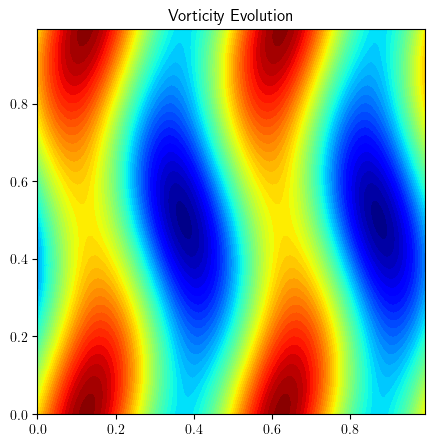

In [7]:
L     = 1.0
N     = 128
nu    = 0.001
dt    = 0.001
tEnd  = 1.0
tOut  = 0.05

x  = np.linspace(0, L, N, endpoint=False)
y  = np.linspace(0, L, N, endpoint=False)
xx, yy = np.meshgrid(x, y)

vx = np.sin(2 * np.pi * yy)
vy = np.cos(2 * np.pi * xx * 2)
speed_init = np.sqrt(vx**2 + vy**2)

k = 2 * np.pi / L * np.fft.fftfreq(N, d=L/N)
kx, ky = np.meshgrid(k, k)
kSq = kx**2 + ky**2
kSq_inv = np.zeros_like(kSq)
kSq_inv[kSq != 0] = 1.0 / kSq[kSq != 0]
wz_frames = []
dealias = (np.abs(kx) < (2/3) * np.max(k)) & (np.abs(ky) < (2/3) * np.max(k))
Nt = int(np.ceil(tEnd / dt))
t = 0
outputCount = 1

for i in range(Nt):
    dvx, dvy = grad(vx), grad(vy)
    rhs_x = -(vx * dvx[0] + vy * dvx[1])
    rhs_y = -(vx * dvy[0] + vy * dvy[1])

    rhs_x = apply_dealias(rhs_x, dealias)
    rhs_y = apply_dealias(rhs_y, dealias)

    vx += dt * rhs_x
    vy += dt * rhs_y

    div_rhs = div(rhs_x, rhs_y)
    P = poisson_solve(div_rhs)
    dPx, dPy = grad(P)

    vx -= dt * dPx
    vy -= dt * dPy

    vx = diffusion_solve(vx)
    vy = diffusion_solve(vy)

    # Vorticity
    wz = np.real(np.fft.ifftn(1j * ky * np.fft.fftn(vx) - 1j * kx * np.fft.fftn(vy)))

    # Time update
    t += dt

    if t + dt > outputCount * tOut:
        wz_frames.append(wz.copy())

fig, ax = plt.subplots(figsize=(5, 5))
ax.set_axis_off()

def update(frame):
    ax.clear()
    cont = ax.contourf(xx, yy, frame, cmap='jet', levels=50)
    ax.set_title("Vorticity Evolution")
    return cont.collections

ani = animation.FuncAnimation( fig, update, frames=wz_frames, interval=80, blit=False)
ani.save("spectral_ns_vorticity.gif", writer="pillow", fps=12)
HTML('<img src="spectral_ns_vorticity.gif" width="600">')

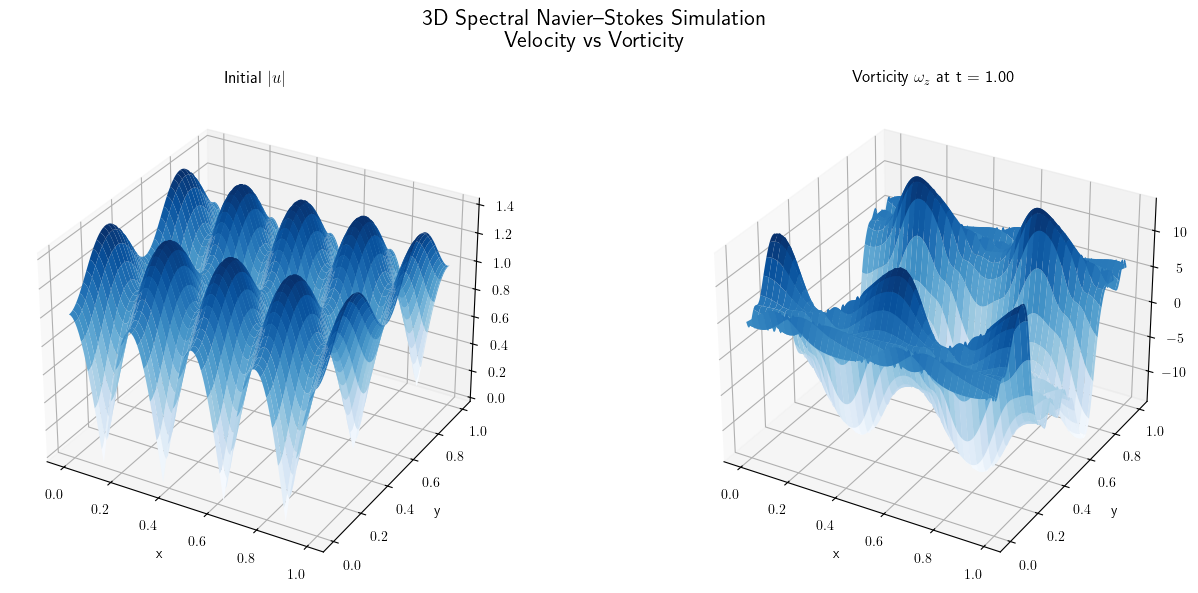

In [11]:
L     = 1.0
N     = 128
nu    = 0.001
dt    = 0.001
tEnd  = 1.0
tOut  = 0.05

x  = np.linspace(0, L, N, endpoint=False)
y  = np.linspace(0, L, N, endpoint=False)
xx, yy = np.meshgrid(x, y)

vx = np.sin(2 * np.pi * yy)
vy = np.cos(2 * np.pi * xx * 2)
speed_init = np.sqrt(vx**2 + vy**2)

k = 2 * np.pi / L * np.fft.fftfreq(N, d=L/N)
kx, ky = np.meshgrid(k, k)
kSq = kx**2 + ky**2
kSq_inv = np.zeros_like(kSq)
kSq_inv[kSq != 0] = 1.0 / kSq[kSq != 0]

dealias = (np.abs(kx) < (2/3) * np.max(k)) & (np.abs(ky) < (2/3) * np.max(k))

Nt = int(np.ceil(tEnd / dt))
t = 0
outputCount = 1

for i in range(Nt):
    dvx, dvy = grad(vx), grad(vy)
    rhs_x = -(vx * dvx[0] + vy * dvx[1])
    rhs_y = -(vx * dvy[0] + vy * dvy[1])

    rhs_x = apply_dealias(rhs_x, dealias)
    rhs_y = apply_dealias(rhs_y, dealias)

    vx += dt * rhs_x
    vy += dt * rhs_y

    div_rhs = div(rhs_x, rhs_y)
    P = poisson_solve(div_rhs)
    dPx, dPy = grad(P)

    vx -= dt * dPx
    vy -= dt * dPy

    vx = diffusion_solve(vx)
    vy = diffusion_solve(vy)

    # Vorticity
    wz = np.real(np.fft.ifftn(1j * ky * np.fft.fftn(vx) - 1j * kx * np.fft.fftn(vy)))

    # Time update
    t += dt

    if t + dt > outputCount * tOut:
        clear_output(wait=True)
        fig, ax = plt.subplots(1, 2, figsize=(14, 6), subplot_kw={"projection": "3d"})

        # ax[0]: initial velocity magnitude
        c0 = ax[0].plot_surface(xx, yy, speed_init, cmap='Blues')
        ax[0].set_title("Initial $|u|$")
        ax[0].set_xlabel("x")
        ax[0].set_ylabel("y")

        # ax[1]: vorticity contour (animated)
        c1 = ax[1].plot_surface(xx, yy, wz, cmap='Blues')
        ax[1].set_title(f"Vorticity $\\omega_z$ at t = {t:.2f}")
        ax[1].set_xlabel("x")
        ax[1].set_ylabel("y")

        plt.suptitle("3D Spectral Navier–Stokes Simulation\nVelocity vs Vorticity", fontsize=16)
        plt.tight_layout()
        plt.show()

        outputCount += 1